# Assignment 2

### Question 1: *git* in Practice

- initialise a repository and push content to the *main* branch
- create and work on a brnach with a descriptive name
- make regular commits with meaninful commit messages
- merge your branch back into *main*

getting access to the gitHub - to be done in a shell
```bash
git clone git@github.com:u7496134/Assignment_2.git
```
This repository has been made using the template given at: https://github.com/svenbuder/template_ojap

### Question 2: Bright Stars Around M67 with ADQL

1. Write an ADQL query that returns all stars in the Gaia DR3 gaiadr3.gaia_source table within 1 degree of M67 with G < 14 and crossmatch them with 2MASS. Report the number of stars returned.

In [7]:
#%pip install astroquery
from astroquery.gaia import Gaia
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.optimize import*
from scipy.stats import binned_statistic_2d
import matplotlib.cm as cm
from io import StringIO
import os
from astropy.io import fits
from matplotlib.colors import LogNorm

Inputted query in the gaia catalogue:


SELECT 
	g.source_id,
	g.ra,
	g.dec,
	g.phot_g_mean_mag,
	g.parallax,
	g.bp_rp,
	t.designation,
	t.j_m,
	t.h_m,
	t.ks_m,
	t.ph_qual,
	DISTANCE(
   		POINT(132.825,11.8),
   		POINT(g.ra,g.dec)) AS ang_sep

FROM gaiadr3.gaia_source AS g

JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS x
	USING (source_id)

JOIN gaiadr3.tmass_psc_xsc_join AS xjoin
	USING (clean_tmass_psc_xsc_oid)

JOIN gaiadr1.tmass_original_valid AS t
	ON xjoin.original_psc_source_id = t.designation

WHERE 1 = CONTAINS(
   POINT(g.ra,g.dec),
   CIRCLE(132.825,11.8,1.0))

AND phot_g_mean_mag < 14
AND g.parallax IS NOT NULL
ORDER BY ang_sep ASC

Using this query, the data outputs from each catalogue was selected to avoid grabbing unnecessary columns - this is determined in the select function.
Distance specifies the point of focus for the search.
The next 3 lines join the various gaia directories from the dr3 and dr1 as dr3 does not contain the 2mass values however the naming conventions have changed throughout each data release so these steps are required.
WHERE creates a cone search looking for stars within 1 degree of the coordinate points and is followed by one of the final categorisations: for all stars less than 14 mag.

This gave a result of 1101 stars.

2. Identify stars with:
    - bad 2MASS photometry
    - non-positive values of Gaia parallax

In [8]:
# loading in the .csv file gotten from the query - stored in the data folder
full_dataset = pd.read_csv('data/assignment2-result.csv')

# assuming we want to cut out the bad photometry
first_cut = full_dataset[full_dataset["ph_qual"] == 'AAA']
final_cut = first_cut[first_cut["parallax"] > 0]

#Finding the number stars remaining
print(len(final_cut))

988


Upon removing the bad photometry and negative parallaxes we have 988 entries remaining - having removed 113 entries.

3. Create and save a two panel figure showing:
    - Gaia BP-RP vs absolute G magnitude
    - 2MASS J-Ks vs apparent H magnitude

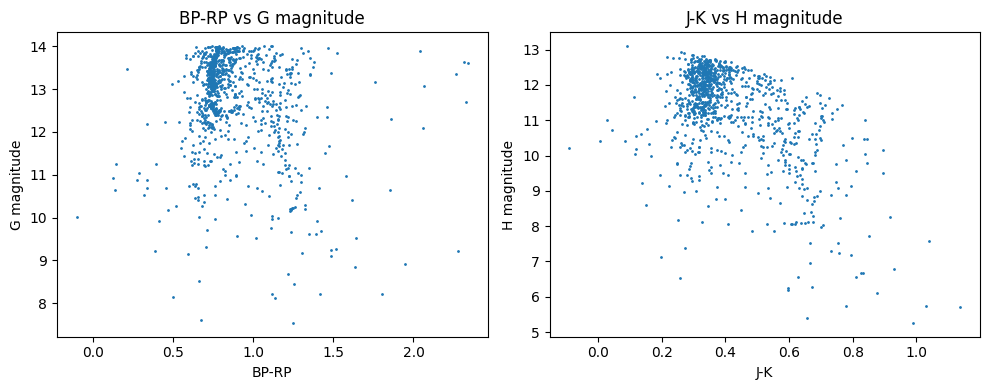

<Figure size 640x480 with 0 Axes>

In [21]:
# creating variables which store the required values
bp_rp = final_cut["bp_rp"] # holds only the specified column values
g_mag = final_cut["phot_g_mean_mag"]
j_m = final_cut["j_m"]
ks_m = final_cut["ks_m"]
h_m = final_cut["h_m"]

j_k = j_m - ks_m

# making the figure

fig, (b_g, jk_h) = plt.subplots(1,2,figsize=(10,4))

b_g.scatter(bp_rp,g_mag,s=1)
b_g.set_title("BP-RP vs G magnitude")
b_g.set_xlabel("BP-RP")
b_g.set_ylabel("G magnitude")

jk_h.scatter(j_k, h_m,s=1)
jk_h.set_title("J-K vs H magnitude")
jk_h.set_xlabel("J-K")
jk_h.set_ylabel("H magnitude")

plt.tight_layout()
plt.show()

# saving figure:
file_path = os.path.join('figures', 'q2_plots.png')
plt.savefig(file_path)


4. Based only upon fibre usage, would you recommend this field for a 2dF/HERMES observing proposal?

Yes, HERMES fibre usage is $\sim 300$, and there are $\sim 900$ entries meaning only three days of observing time is needed/required.

### Question 3: Radial Metallicity Relations Simulations

The radial metallicity relation describes the change of metallicity– here the gas-phase metallicity $A(O) = log_{10}(N_O/N_H) + 12$ -  with galactocentric cylindrical radius $R_{Gal}$.  Radial metallicity gradients provide insight into processes such as inside-out formation, gas accretion, outflows, and radial migration. A lot of work has been done through observational studies and a few simulations but more works is needed to understand variations of the radial metallicity gradient.

1. Plot a two-panel figure:
    -  logarithmic density plot of $R_{Gal}$. vs. A(O), with a linear fit and legend;
    -  residuals of the fit, $R_{Gal}$. vs. $∆A(O)$.

In [2]:
# calling upon the file for use
data = fits.open("data/metal_relations.fits")
metal_relations = np.array(data[1].data)

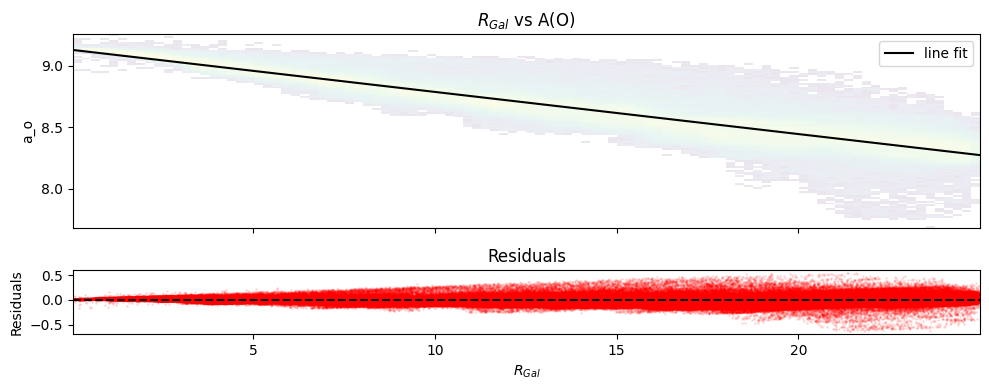

In [4]:
# calculating R_{Gal}
x_pos = metal_relations['x']
y_pos = metal_relations['y']
a_o = metal_relations['A_O']
r_gal = np.sqrt((x_pos**2) + (y_pos**2))


m, b = np.polyfit(r_gal, a_o, 1) # 1 means linear
fit = m * r_gal + b
resid1 = a_o - fit

# plotting so they are stacked on top of each other
fig, (rgal_ao, residuals) = plt.subplots(
    2,1,
    figsize=(10,4),
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]}) # making the second plot 1/3 the size

# R_gal vs A(O) (top pannel)
top = rgal_ao.hist2d(
    r_gal, a_o,
    bins=100,
    norm=LogNorm(),
    alpha = 0.1
)

# making the fit
x_line = np.linspace(r_gal.min(), r_gal.max(), 1000)
rgal_ao.plot(
    x_line,
    m * x_line + b,
    color='black',
    label='line fit'
)

rgal_ao.set_title("$R_{Gal}$ vs A(O)")
rgal_ao.set_ylabel("a_o")
rgal_ao.legend()

# bottom pannel: residuals
residuals.scatter(
    r_gal,
    resid1,
    s=1,
    alpha=0.1,
    color="red"
)

#final plotting
residuals.axhline(0,color='black', linestyle="--")
residuals.set_xlabel("$R_{Gal}$")
residuals.set_ylabel("Residuals")
residuals.set_title("Residuals")
plt.tight_layout()
plt.show()


# # saving figure:
# file_path = os.path.join('figures', 'q3_1_plots_with_linear_fit.png')
# plt.savefig(file_path)


2.  Use a python fitting tool to fit a linear function to the data, reporting the intercept and slope with uncertainties. Include any hyperparameters used.

/tmp/ipykernel_1534109/365603787.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  rgal_ao.legend()


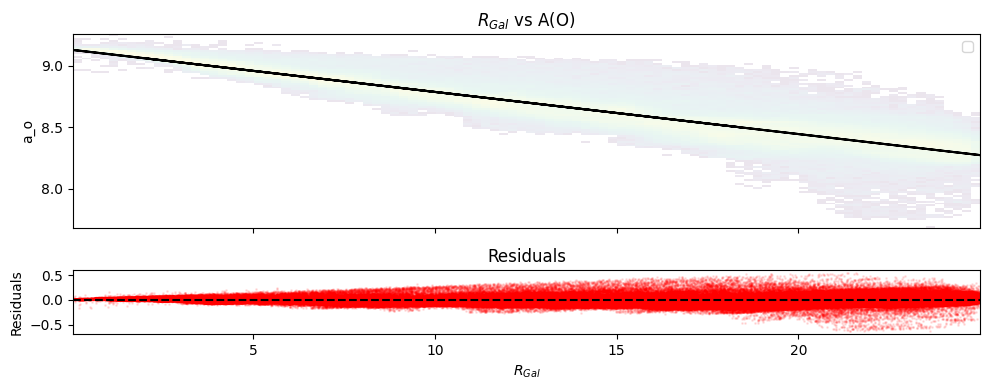

In [5]:
#defining the model function: linear
def linear_fit(x, a, b):
    return a * x + b

#using the same start as above
# plotting so they are stacked on top of each other
fig, (rgal_ao, residuals) = plt.subplots(
    2,1,
    figsize=(10,4),
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]}) # making the second plot 1/3 the size

# R_gal vs A(O) (top pannel)
top = rgal_ao.hist2d(
    r_gal, a_o,
    bins=100,
    norm=LogNorm(),
    alpha = 0.1
)

# fitting curve using scipy curve_fit
int_guess = [1.0, 1.0] # [a, b]
popt, pcov = curve_fit(linear_fit, r_gal, a_o, p0=int_guess) #used the variable names from documentation
a_opt, b_opt = popt
perr = np.sqrt(np.diag(pcov)) #std of parameters

#plotting top panel
rgal_ao.set_title("$R_{Gal}$ vs A(O)")
rgal_ao.set_ylabel("a_o")
rgal_ao.legend()
rgal_ao.plot(
    r_gal,
    linear_fit(r_gal, *popt),
    color='black',
    label='line fit'
)

# bottom pannel: residuals
resid2 = a_o - linear_fit(r_gal, *popt)
residuals.scatter(
    r_gal,
    resid2,
    s=1,
    alpha=0.1,
    color="red"
)

#final plotting

residuals.axhline(0,color='black', linestyle="--")
residuals.set_xlabel("$R_{Gal}$")
residuals.set_ylabel("Residuals")
residuals.set_title("Residuals")

plt.tight_layout()
plt.show()

# file_path = os.path.join('figures', 'q3_2_plots_with_curve_fit.png')
# plt.savefig(file_path)


3. Discuss where the linear model fits well and where it does not. Use statistical metrics, such as the root mean square or another goodness-of-fit indicator, to quantify its performance overall and in regions with larger residuals.

To do this throot mean square, or the rmse version will be used, given by:
$$
RMSE = \sqrt(mean(residuals^2))
$$

In [6]:
resid1_2 = resid1**2
resid2_2 = resid2**2

rmse1 = np.sqrt(np.mean(resid1_2))
rmse2 = np.sqrt(np.mean(resid2_2))

print(rmse1, rmse2)

0.07264613629071141 0.07264613629071141


The rmse from both linear fit versions (polyfit, curve_fit) came out to be $RMSE \approx 0.07265$. From the visual of the fit the line makes a reasonable fit to the densest parts of the plot, however as the $R_{Gal}$ increase the scatter from the line increases (also replicated within the residuals). However the fit seems appropriate from visual inspection with backing from the RSME value. 

4.  Plot a three-panel figure for the x vs. y plane using the same bins and sensible colormaps:
    - (a) 2D histogram of the median simulated A(O);
    - (b) 2D histogram of the median fitted A(O);
    - (c) 2D histogram of the median residuals ∆A(O).

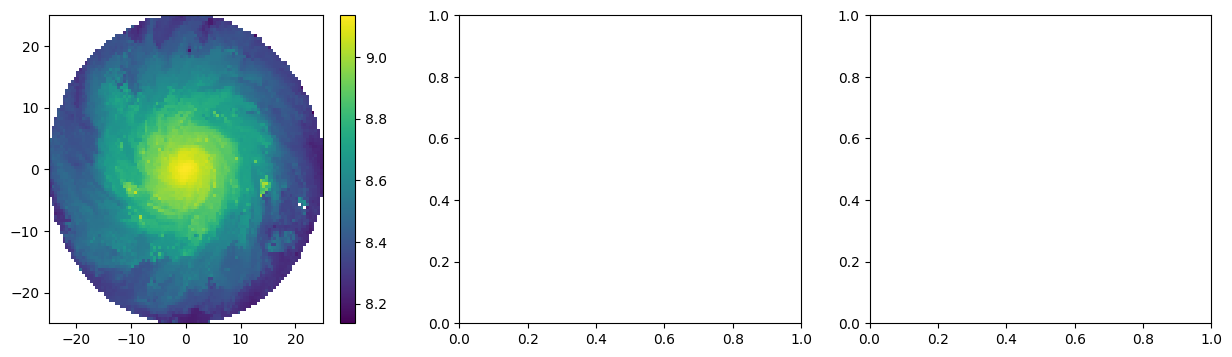

In [9]:
fig, (a, b, c) = plt.subplots(1,3,figsize=(15,4))
# Plotting 1/3 plots - a) 2D histogram of median simulated A(O)
median_sim_ao, xedges_a, yedges_a, binnumber = binned_statistic_2d(
    x_pos,
    y_pos,
    a_o,
    statistic='median',
    bins=100
)

plot_a = a.pcolormesh(
    xedges_a,
    yedges_a,
    median_sim_ao.T,
    shading='auto'
)

fig.colorbar(plot_a, ax=a)